In [2]:
# Final Independent Evaluation

## Frozen Ridge Model on the 2024–2025 Test Period

This notebook performs the final independent evaluation of the one-month-ahead hydroclimatic water-stress forecasting model.

The model specification was frozen in Notebook 04 before any test-period evaluation:

- Model: Ridge Regression
- Forecast horizon: 1 month
- Number of predictors: 15
- Ridge α: 0.05

The final model is refitted using the combined training and validation observations from July 2015 to December 2023 and evaluated once on the untouched January 2024 to December 2025 test period.

Performance is compared against:

1. a persistence baseline; and
2. a climatological-normal baseline.

Additional analyses include residual diagnostics, year-by-year performance, sensitivity to the May 2024 extreme event, performance under extreme and non-extreme conditions, and standardized Ridge coefficient interpretation.

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (635733828.py, line 7)

In [3]:
# ============================================================
# LOAD MODELING DATASET AND FROZEN MODEL SPECIFICATION
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project data directory."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODELING_FILE = (
    PROCESSED_DIR /
    "mnjoli_water_stress_modeling_dataset.csv"
)

SPECIFICATION_FILE = (
    PROCESSED_DIR /
    "final_model_specification.json"
)


# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

df_model = pd.read_csv(
    MODELING_FILE,
    parse_dates=[
        "month_date",
        "forecast_date"
    ]
)

df_model = (
    df_model
    .sort_values("forecast_date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# LOAD FROZEN MODEL SPECIFICATION
# ------------------------------------------------------------

with open(
    SPECIFICATION_FILE,
    "r",
    encoding="utf-8"
) as file:

    specification = json.load(file)


# ------------------------------------------------------------
# EXTRACT FINAL MODEL SETTINGS
# ------------------------------------------------------------

TARGET = "target_t_plus_1"

selected_features = (
    specification[
        "selected_features"
    ]
)

ridge_alpha = float(
    specification[
        "ridge_alpha"
    ]
)


# ------------------------------------------------------------
# BASIC VERIFICATION
# ------------------------------------------------------------

print("=" * 70)
print("FINAL EVALUATION INPUTS")
print("=" * 70)

print(
    "Dataset shape:",
    df_model.shape
)

print(
    "Forecast period:",
    df_model["forecast_date"].min(),
    "to",
    df_model["forecast_date"].max()
)

print(
    "Final model:",
    specification["model"]
)

print(
    "Selected features:",
    len(selected_features)
)

print(
    "Ridge alpha:",
    ridge_alpha
)

print(
    "Missing values:",
    df_model.isna().sum().sum()
)


# ------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------

assert (
    specification["model"]
    == "Ridge Regression"
)

assert (
    len(selected_features)
    == 15
)

assert np.isclose(
    ridge_alpha,
    0.05
)

assert (
    df_model.isna().sum().sum()
    == 0
)

print(
    "\nPASS — frozen model specification loaded successfully."
)

FINAL EVALUATION INPUTS
Dataset shape: (126, 62)
Forecast period: 2015-07-01 00:00:00 to 2025-12-01 00:00:00
Final model: Ridge Regression
Selected features: 15
Ridge alpha: 0.05
Missing values: 0

PASS — frozen model specification loaded successfully.


In [4]:
# ============================================================
# FINAL REFIT AND INDEPENDENT TEST SET
# ============================================================
print("Cell 3 started")
TEST_START = pd.Timestamp("2024-01-01")


# ------------------------------------------------------------
# 1. DEFINE DEVELOPMENT AND TEST PERIODS
# ------------------------------------------------------------

development_mask = (
    df_model["forecast_date"]
    < TEST_START
)

test_mask = (
    df_model["forecast_date"]
    >= TEST_START
)


# ------------------------------------------------------------
# 2. BUILD FEATURE MATRICES
# ------------------------------------------------------------

X_development = (
    df_model.loc[
        development_mask,
        selected_features
    ]
    .copy()
)

y_development = (
    df_model.loc[
        development_mask,
        TARGET
    ]
    .copy()
)

X_test = (
    df_model.loc[
        test_mask,
        selected_features
    ]
    .copy()
)

y_test = (
    df_model.loc[
        test_mask,
        TARGET
    ]
    .copy()
)

test_dates = (
    df_model.loc[
        test_mask,
        "forecast_date"
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. VERIFY CHRONOLOGICAL SEPARATION
# ------------------------------------------------------------

print("=" * 70)
print("FINAL DEVELOPMENT / TEST SPLIT")
print("=" * 70)

print("\nDevelopment period:")

print(
    df_model.loc[
        development_mask,
        "forecast_date"
    ].min(),
    "to",
    df_model.loc[
        development_mask,
        "forecast_date"
    ].max()
)

print(
    "Development observations:",
    len(X_development)
)

print("\nIndependent test period:")

print(
    test_dates.min(),
    "to",
    test_dates.max()
)

print(
    "Test observations:",
    len(X_test)
)


# ------------------------------------------------------------
# 4. BUILD FROZEN RIDGE PIPELINE
# ------------------------------------------------------------

final_ridge = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "ridge",
        Ridge(
            alpha=ridge_alpha
        )
    )
])


# ------------------------------------------------------------
# 5. REFIT USING ALL PRE-TEST OBSERVATIONS
# ------------------------------------------------------------

final_ridge.fit(
    X_development,
    y_development
)


# ------------------------------------------------------------
# 6. TEST PREDICTIONS
# ------------------------------------------------------------

ridge_predictions = (
    final_ridge.predict(
        X_test
    )
)


# ------------------------------------------------------------
# 7. SAFETY ASSERTIONS
# ------------------------------------------------------------

assert len(X_development) == 102, (
    "Unexpected number of development observations."
)

assert len(X_test) == 24, (
    "Unexpected number of independent test observations."
)

assert (
    test_dates.min()
    == pd.Timestamp("2024-01-01")
)

assert (
    test_dates.max()
    == pd.Timestamp("2025-12-01")
)

print(
    "\nPASS — final model refitted on 102 pre-test observations "
    "and evaluated on 24 untouched test observations."
)

Cell 3 started
FINAL DEVELOPMENT / TEST SPLIT

Development period:
2015-07-01 00:00:00 to 2023-12-01 00:00:00
Development observations: 102

Independent test period:
2024-01-01 00:00:00 to 2025-12-01 00:00:00
Test observations: 24

PASS — final model refitted on 102 pre-test observations and evaluated on 24 untouched test observations.


In [5]:
# ============================================================
# OFFICIAL INDEPENDENT TEST PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# 1. RIDGE TEST METRICS
# ------------------------------------------------------------

ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_predictions
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)


# ------------------------------------------------------------
# 2. PERSISTENCE BASELINE
# ------------------------------------------------------------
# Persistence assumes the next month's WSI is equal to the
# current month's WSI.
#
# The current-month WSI is reconstructed from the target
# sequence by using the previous month's observed target.
# ------------------------------------------------------------

test_rows = (
    df_model.loc[
        test_mask,
        [
            "month_date",
            "forecast_date",
            TARGET
        ]
    ]
    .copy()
)

# For each test forecast month, persistence uses the WSI from
# the immediately preceding month.
#
# Since target_t_plus_1 on row t equals WSI at forecast_date,
# we can obtain persistence from the previous target value in
# the full chronological modeling dataset.

full_target_series = (
    df_model[
        [
            "forecast_date",
            TARGET
        ]
    ]
    .copy()
)

full_target_series[
    "persistence"
] = (
    full_target_series[
        TARGET
    ]
    .shift(1)
)

test_baseline_data = (
    test_rows[
        [
            "forecast_date",
            TARGET
        ]
    ]
    .merge(
        full_target_series[
            [
                "forecast_date",
                "persistence"
            ]
        ],
        on="forecast_date",
        how="left"
    )
)

persistence_predictions = (
    test_baseline_data[
        "persistence"
    ]
    .to_numpy()
)


# ------------------------------------------------------------
# 3. CLIMATOLOGY BASELINE
# ------------------------------------------------------------
# The standardized water-stress index is centered relative to
# the training-period climatology, so climatological-normal
# conditions correspond to WSI = 0.
# ------------------------------------------------------------

climatology_predictions = np.zeros(
    len(y_test)
)


# ------------------------------------------------------------
# 4. BASELINE METRICS
# ------------------------------------------------------------

persistence_mae = mean_absolute_error(
    y_test,
    persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_predictions
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_predictions
)

climatology_mae = mean_absolute_error(
    y_test,
    climatology_predictions
)

climatology_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        climatology_predictions
    )
)

climatology_r2 = r2_score(
    y_test,
    climatology_predictions
)


# ------------------------------------------------------------
# 5. PERFORMANCE TABLE
# ------------------------------------------------------------

performance_results = pd.DataFrame([
    {
        "Model": "Final Ridge t+1",
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2
    },
    {
        "Model": "Persistence",
        "MAE": persistence_mae,
        "RMSE": persistence_rmse,
        "R2": persistence_r2
    },
    {
        "Model": "Climatology (WSI=0)",
        "MAE": climatology_mae,
        "RMSE": climatology_rmse,
        "R2": climatology_r2
    }
])


# ------------------------------------------------------------
# 6. IMPROVEMENT OVER BASELINES
# ------------------------------------------------------------

rmse_improvement_persistence = (
    (
        persistence_rmse
        - ridge_rmse
    )
    / persistence_rmse
    * 100
)

rmse_improvement_climatology = (
    (
        climatology_rmse
        - ridge_rmse
    )
    / climatology_rmse
    * 100
)

mae_improvement_persistence = (
    (
        persistence_mae
        - ridge_mae
    )
    / persistence_mae
    * 100
)


# ------------------------------------------------------------
# 7. DISPLAY OFFICIAL RESULTS
# ------------------------------------------------------------

print("=" * 70)
print("OFFICIAL INDEPENDENT TEST PERFORMANCE")
print("=" * 70)

print(
    performance_results
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 70)
print("IMPROVEMENT OVER BASELINES")
print("=" * 70)

print(
    "MAE improvement over persistence:",
    f"{mae_improvement_persistence:.2f}%"
)

print(
    "RMSE improvement over persistence:",
    f"{rmse_improvement_persistence:.2f}%"
)

print(
    "RMSE improvement over climatology:",
    f"{rmse_improvement_climatology:.2f}%"
)


# ------------------------------------------------------------
# 8. SAFETY CHECKS
# ------------------------------------------------------------

assert len(ridge_predictions) == 24
assert len(persistence_predictions) == 24
assert len(climatology_predictions) == 24

assert not np.isnan(
    persistence_predictions
).any(), (
    "Persistence baseline contains missing values."
)

print(
    "\nPASS — official test evaluation completed "
    "without altering the frozen model specification."
)

OFFICIAL INDEPENDENT TEST PERFORMANCE
              Model    MAE   RMSE      R2
    Final Ridge t+1 0.9625 1.3906  0.2124
        Persistence 1.0290 1.7568 -0.2570
Climatology (WSI=0) 1.1358 1.7589 -0.2600

IMPROVEMENT OVER BASELINES
MAE improvement over persistence: 6.46%
RMSE improvement over persistence: 20.84%
RMSE improvement over climatology: 20.93%

PASS — official test evaluation completed without altering the frozen model specification.


In [6]:
# ============================================================
# TEST PREDICTIONS AND RESIDUAL DIAGNOSTICS
# ============================================================

# ------------------------------------------------------------
# 1. BUILD TEST-RESULTS TABLE
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "forecast_date": test_dates.to_numpy(),
    "observed": y_test.to_numpy(),
    "ridge_forecast": ridge_predictions,
    "persistence": persistence_predictions,
    "climatology": climatology_predictions
})


# ------------------------------------------------------------
# 2. CALCULATE RIDGE RESIDUALS
# ------------------------------------------------------------
# Residual = observed - forecast
#
# Positive residual:
#     Ridge underpredicted the observed WSI.
#
# Negative residual:
#     Ridge overpredicted the observed WSI.
# ------------------------------------------------------------

test_results["residual"] = (
    test_results["observed"]
    - test_results["ridge_forecast"]
)

test_results["absolute_error"] = (
    test_results["residual"]
    .abs()
)


# ------------------------------------------------------------
# 3. RESIDUAL SUMMARY
# ------------------------------------------------------------

mean_residual = (
    test_results["residual"]
    .mean()
)

residual_std = (
    test_results["residual"]
    .std(ddof=1)
)

maximum_absolute_error = (
    test_results["absolute_error"]
    .max()
)


print("=" * 70)
print("RIDGE TEST RESIDUAL DIAGNOSTICS")
print("=" * 70)

print(
    "Mean residual:",
    round(mean_residual, 4)
)

print(
    "Residual standard deviation:",
    round(residual_std, 4)
)

print(
    "Mean absolute error:",
    round(ridge_mae, 4)
)

print(
    "Maximum absolute error:",
    round(maximum_absolute_error, 4)
)


# ------------------------------------------------------------
# 4. DISPLAY ALL TEST FORECASTS
# ------------------------------------------------------------

display_results = (
    test_results
    .copy()
)

numeric_columns = (
    display_results
    .select_dtypes(include=[np.number])
    .columns
)

display_results[numeric_columns] = (
    display_results[numeric_columns]
    .round(4)
)

print("\n" + "=" * 70)
print("MONTHLY INDEPENDENT TEST FORECASTS")
print("=" * 70)

display(display_results)


# ------------------------------------------------------------
# 5. IDENTIFY LARGEST FORECAST ERRORS
# ------------------------------------------------------------

largest_errors = (
    test_results
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(10)
    .copy()
)

numeric_columns = (
    largest_errors
    .select_dtypes(include=[np.number])
    .columns
)

largest_errors[numeric_columns] = (
    largest_errors[numeric_columns]
    .round(4)
)

print("\n" + "=" * 70)
print("10 LARGEST RIDGE FORECAST ERRORS")
print("=" * 70)

display(
    largest_errors[
        [
            "forecast_date",
            "observed",
            "ridge_forecast",
            "residual",
            "absolute_error"
        ]
    ]
)


# ------------------------------------------------------------
# 6. BIAS INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESIDUAL BIAS INTERPRETATION")
print("=" * 70)

if mean_residual > 0:

    print(
        "Positive mean residual detected."
    )

    print(
        "The Ridge model tends, on average, "
        "to UNDERPREDICT the observed water-stress index."
    )

elif mean_residual < 0:

    print(
        "Negative mean residual detected."
    )

    print(
        "The Ridge model tends, on average, "
        "to OVERPREDICT the observed water-stress index."
    )

else:

    print(
        "Mean residual is approximately zero."
    )


# ------------------------------------------------------------
# 7. EXPECTED RESULT CHECKS
# ------------------------------------------------------------

assert np.isclose(
    ridge_mae,
    0.9625,
    atol=0.0001
)

assert np.isclose(
    ridge_rmse,
    1.3906,
    atol=0.0001
)

assert np.isclose(
    ridge_r2,
    0.2124,
    atol=0.0001
)

print(
    "\nPASS — monthly forecasts reproduce "
    "the official independent-test results."
)

RIDGE TEST RESIDUAL DIAGNOSTICS
Mean residual: 0.5274
Residual standard deviation: 1.3144
Mean absolute error: 0.9625
Maximum absolute error: 5.1248

MONTHLY INDEPENDENT TEST FORECASTS


,forecast_date,observed,ridge_forecast,persistence,climatology,residual,absolute_error
0,2024-01-01,0.6592,0.6808,1.1365,0.0,-0.0216,0.0216
1,2024-02-01,0.1948,1.2087,0.6592,0.0,-1.0138,1.0138
2,2024-03-01,0.9950,-0.7691,0.1948,0.0,1.7641,1.7641
3,2024-04-01,2.0794,1.2341,0.9950,0.0,0.8453,0.8453
4,2024-05-01,7.0614,1.9365,2.0794,0.0,5.1248,5.1248
5,2024-06-01,1.3644,-0.1616,7.0614,0.0,1.5260,1.5260
6,2024-07-01,-0.6764,-0.1716,1.3644,0.0,-0.5048,0.5048
7,2024-08-01,-1.0491,-0.2326,-0.6764,0.0,-0.8165,0.8165
8,2024-09-01,-0.7537,-0.0850,-1.0491,0.0,-0.6688,0.6688
9,2024-10-01,0.4731,0.0656,-0.7537,0.0,0.4075,0.4075



10 LARGEST RIDGE FORECAST ERRORS


,forecast_date,observed,ridge_forecast,residual,absolute_error
4,2024-05-01,7.0614,1.9365,5.1248,5.1248
22,2025-11-01,1.9902,-0.1786,2.1688,2.1688
2,2024-03-01,0.9950,-0.7691,1.7641,1.7641
5,2024-06-01,1.3644,-0.1616,1.5260,1.5260
21,2025-10-01,0.8245,-0.5750,1.3995,1.3995
20,2025-09-01,1.0983,-0.1096,1.2079,1.2079
1,2024-02-01,0.1948,1.2087,-1.0138,1.0138
18,2025-07-01,-0.7045,0.2256,-0.9301,0.9301
3,2024-04-01,2.0794,1.2341,0.8453,0.8453
7,2024-08-01,-1.0491,-0.2326,-0.8165,0.8165



RESIDUAL BIAS INTERPRETATION
Positive mean residual detected.
The Ridge model tends, on average, to UNDERPREDICT the observed water-stress index.

PASS — monthly forecasts reproduce the official independent-test results.


In [7]:
# ============================================================
# ROBUSTNESS AND SENSITIVITY ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. YEAR-BY-YEAR PERFORMANCE
# ------------------------------------------------------------

test_results["year"] = (
    pd.to_datetime(
        test_results["forecast_date"]
    ).dt.year
)

yearly_results = []

for year, group in test_results.groupby("year"):

    y_obs = group["observed"]
    y_pred = group["ridge_forecast"]

    yearly_results.append({
        "Year": year,
        "N": len(group),
        "MAE": mean_absolute_error(
            y_obs,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_obs,
                y_pred
            )
        ),
        "R2": r2_score(
            y_obs,
            y_pred
        ),
        "Mean_Residual": group[
            "residual"
        ].mean(),
        "Maximum_Error": group[
            "absolute_error"
        ].max()
    })

yearly_results = pd.DataFrame(
    yearly_results
)


print("=" * 70)
print("YEAR-BY-YEAR RIDGE PERFORMANCE")
print("=" * 70)

display(
    yearly_results.round(4)
)


# ------------------------------------------------------------
# 2. YEAR-BY-YEAR BASELINE COMPARISON
# ------------------------------------------------------------

yearly_baselines = []

for year, group in test_results.groupby("year"):

    observed = group["observed"]

    ridge = group["ridge_forecast"]
    persistence = group["persistence"]
    climatology = group["climatology"]

    yearly_baselines.append({

        "Year": year,

        "Ridge_MAE":
            mean_absolute_error(
                observed,
                ridge
            ),

        "Persistence_MAE":
            mean_absolute_error(
                observed,
                persistence
            ),

        "Climatology_MAE":
            mean_absolute_error(
                observed,
                climatology
            ),

        "Ridge_RMSE":
            np.sqrt(
                mean_squared_error(
                    observed,
                    ridge
                )
            ),

        "Persistence_RMSE":
            np.sqrt(
                mean_squared_error(
                    observed,
                    persistence
                )
            ),

        "Climatology_RMSE":
            np.sqrt(
                mean_squared_error(
                    observed,
                    climatology
                )
            )
    })


yearly_baselines = pd.DataFrame(
    yearly_baselines
)


print("\n" + "=" * 70)
print("YEAR-BY-YEAR BASELINE COMPARISON")
print("=" * 70)

display(
    yearly_baselines.round(4)
)


# ------------------------------------------------------------
# 3. MAY 2024 SENSITIVITY ANALYSIS
# ------------------------------------------------------------
# May 2024 contains the largest WSI in the independent test
# period and the largest Ridge forecast error.
#
# The official metrics MUST retain this observation.
# This analysis only measures its influence on aggregate
# performance.
# ------------------------------------------------------------

may_2024 = pd.Timestamp(
    "2024-05-01"
)

sensitivity_data = (
    test_results.loc[
        test_results["forecast_date"]
        != may_2024
    ]
    .copy()
)


sensitivity_mae = mean_absolute_error(
    sensitivity_data["observed"],
    sensitivity_data["ridge_forecast"]
)

sensitivity_rmse = np.sqrt(
    mean_squared_error(
        sensitivity_data["observed"],
        sensitivity_data["ridge_forecast"]
    )
)

sensitivity_r2 = r2_score(
    sensitivity_data["observed"],
    sensitivity_data["ridge_forecast"]
)


sensitivity_summary = pd.DataFrame([
    {
        "Evaluation":
            "Official test — all observations",
        "N": len(test_results),
        "MAE": ridge_mae,
        "RMSE": ridge_rmse,
        "R2": ridge_r2
    },
    {
        "Evaluation":
            "Sensitivity — excluding May 2024",
        "N": len(sensitivity_data),
        "MAE": sensitivity_mae,
        "RMSE": sensitivity_rmse,
        "R2": sensitivity_r2
    }
])


print("\n" + "=" * 70)
print("MAY 2024 SENSITIVITY ANALYSIS")
print("=" * 70)

display(
    sensitivity_summary.round(4)
)


mae_reduction = (
    (
        ridge_mae
        - sensitivity_mae
    )
    / ridge_mae
    * 100
)

rmse_reduction = (
    (
        ridge_rmse
        - sensitivity_rmse
    )
    / ridge_rmse
    * 100
)


print(
    "MAE decreases by",
    f"{mae_reduction:.2f}%",
    "when May 2024 is excluded."
)

print(
    "RMSE decreases by",
    f"{rmse_reduction:.2f}%",
    "when May 2024 is excluded."
)


# ------------------------------------------------------------
# 4. EXTREME-VALUE PERFORMANCE
# ------------------------------------------------------------
# Extreme WSI is defined here as |WSI| >= 2.
# ------------------------------------------------------------

EXTREME_THRESHOLD = 2.0

extreme_mask = (
    test_results["observed"].abs()
    >= EXTREME_THRESHOLD
)

extreme_results = (
    test_results.loc[
        extreme_mask
    ]
    .copy()
)

non_extreme_results = (
    test_results.loc[
        ~extreme_mask
    ]
    .copy()
)


print("\n" + "=" * 70)
print("EXTREME-VALUE ANALYSIS")
print("=" * 70)

print(
    "Observations with |WSI| >= 2:",
    len(extreme_results)
)

print(
    "Observations with |WSI| < 2 :",
    len(non_extreme_results)
)


print("\nExtreme observations:")

display(
    extreme_results[
        [
            "forecast_date",
            "observed",
            "ridge_forecast",
            "residual",
            "absolute_error"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 5. EXTREME / NON-EXTREME METRICS
# ------------------------------------------------------------

extreme_mae = mean_absolute_error(
    extreme_results["observed"],
    extreme_results["ridge_forecast"]
)

extreme_rmse = np.sqrt(
    mean_squared_error(
        extreme_results["observed"],
        extreme_results["ridge_forecast"]
    )
)

non_extreme_mae = mean_absolute_error(
    non_extreme_results["observed"],
    non_extreme_results["ridge_forecast"]
)

non_extreme_rmse = np.sqrt(
    mean_squared_error(
        non_extreme_results["observed"],
        non_extreme_results["ridge_forecast"]
    )
)


print(
    "\nExtreme-value MAE :",
    round(extreme_mae, 4)
)

print(
    "Extreme-value RMSE:",
    round(extreme_rmse, 4)
)

print(
    "\nNon-extreme MAE :",
    round(non_extreme_mae, 4)
)

print(
    "Non-extreme RMSE:",
    round(non_extreme_rmse, 4)
)


# ------------------------------------------------------------
# 6. VERIFICATION
# ------------------------------------------------------------

assert len(extreme_results) == 2
assert len(non_extreme_results) == 22

assert (
    pd.Timestamp("2024-05-01")
    in extreme_results["forecast_date"].values
)

print(
    "\nPASS — robustness and sensitivity analyses completed."
)

YEAR-BY-YEAR RIDGE PERFORMANCE


,Year,N,MAE,RMSE,R2,Mean_Residual,Maximum_Error
0,2024,12,1.1069,1.7119,0.314,0.5403,5.1248
1,2025,12,0.8181,0.9680,-0.479,0.5145,2.1688



YEAR-BY-YEAR BASELINE COMPARISON


,Year,Ridge_MAE,Persistence_MAE,Climatology_MAE,Ridge_RMSE,Persistence_RMSE,Climatology_RMSE
0,2024,1.1069,1.5053,1.2905,1.7119,2.3399,2.2339
1,2025,0.8181,0.5527,0.9811,0.9680,0.8352,1.0940



MAY 2024 SENSITIVITY ANALYSIS


,Evaluation,N,MAE,RMSE,R2
0,Official test — all observations,24,0.9625,1.3906,0.2124
1,Sensitivity — excluding May 2024,23,0.7815,0.9360,-0.1192


MAE decreases by 18.80% when May 2024 is excluded.
RMSE decreases by 32.69% when May 2024 is excluded.

EXTREME-VALUE ANALYSIS
Observations with |WSI| >= 2: 2
Observations with |WSI| < 2 : 22

Extreme observations:


C:\Users\Para\AppData\Local\Temp\ipykernel_10096\2189347173.py:294: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(4)


,forecast_date,observed,ridge_forecast,residual,absolute_error
3,2024-04-01,2.0794,1.2341,0.8453,0.8453
4,2024-05-01,7.0614,1.9365,5.1248,5.1248



Extreme-value MAE : 2.9851
Extreme-value RMSE: 3.6728

Non-extreme MAE : 0.7786
Non-extreme RMSE: 0.9399

PASS — robustness and sensitivity analyses completed.


In [8]:
# ============================================================
# FINAL RIDGE COEFFICIENT INTERPRETATION
# ============================================================

# ------------------------------------------------------------
# 1. EXTRACT FITTED RIDGE ESTIMATOR
# ------------------------------------------------------------

ridge_estimator = (
    final_ridge
    .named_steps["ridge"]
)

scaler = (
    final_ridge
    .named_steps["scaler"]
)


# ------------------------------------------------------------
# 2. BUILD COEFFICIENT TABLE
# ------------------------------------------------------------
# Because predictors are standardized before Ridge fitting,
# coefficient magnitudes are comparable across variables.
# ------------------------------------------------------------

coefficient_table = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": ridge_estimator.coef_
})

coefficient_table[
    "Absolute_Coefficient"
] = (
    coefficient_table[
        "Coefficient"
    ].abs()
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficient_table.insert(
    0,
    "Rank",
    range(
        1,
        len(coefficient_table) + 1
    )
)


# ------------------------------------------------------------
# 3. DISPLAY FINAL COEFFICIENTS
# ------------------------------------------------------------

print("=" * 70)
print("FINAL STANDARDIZED RIDGE COEFFICIENTS")
print("=" * 70)

print(
    coefficient_table
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 4. POSITIVE / NEGATIVE RELATIONSHIPS
# ------------------------------------------------------------

positive_coefficients = (
    coefficient_table.loc[
        coefficient_table[
            "Coefficient"
        ] > 0
    ]
    .copy()
)

negative_coefficients = (
    coefficient_table.loc[
        coefficient_table[
            "Coefficient"
        ] < 0
    ]
    .copy()
)


print("\n" + "=" * 70)
print("COEFFICIENT DIRECTION")
print("=" * 70)

print(
    "Positive coefficients:",
    len(positive_coefficients)
)

print(
    "Negative coefficients:",
    len(negative_coefficients)
)


print("\nPositive relationships:")

display(
    positive_coefficients[
        [
            "Feature",
            "Coefficient"
        ]
    ].round(4)
)


print("\nNegative relationships:")

display(
    negative_coefficients[
        [
            "Feature",
            "Coefficient"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# 5. TOP FIVE FEATURES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP FIVE MODEL CONTRIBUTORS")
print("=" * 70)

display(
    coefficient_table[
        [
            "Rank",
            "Feature",
            "Coefficient",
            "Absolute_Coefficient"
        ]
    ]
    .head(5)
    .round(4)
)


# ------------------------------------------------------------
# 6. INTERPRETATION NOTE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTERPRETATION NOTE")
print("=" * 70)

print(
    "Because predictors were standardized before Ridge fitting, "
    "absolute coefficient magnitudes can be compared as indicators "
    "of relative model influence."
)

print(
    "Coefficient signs represent predictive associations within "
    "the multivariable model and should not be interpreted as "
    "causal hydroclimatic effects."
)

print(
    "Correlated predictors may redistribute coefficient magnitude "
    "and sign across related variables."
)


# ------------------------------------------------------------
# 7. FINAL NOTEBOOK SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(
    "Model: Ridge Regression"
)

print(
    "Forecast horizon: 1 month"
)

print(
    "Predictors:",
    len(selected_features)
)

print(
    "Alpha:",
    ridge_alpha
)

print(
    "\nIndependent test period:",
    test_dates.min(),
    "to",
    test_dates.max()
)

print(
    "Test observations:",
    len(y_test)
)

print(
    "\nMAE:",
    round(ridge_mae, 4)
)

print(
    "RMSE:",
    round(ridge_rmse, 4)
)

print(
    "R²:",
    round(ridge_r2, 4)
)

print(
    "\nRMSE improvement over persistence:",
    f"{rmse_improvement_persistence:.2f}%"
)

print(
    "RMSE improvement over climatology:",
    f"{rmse_improvement_climatology:.2f}%"
)

print(
    "\nMean residual:",
    round(mean_residual, 4)
)

print(
    "Maximum absolute error:",
    round(maximum_absolute_error, 4)
)


# ------------------------------------------------------------
# 8. COMPLETION CHECK
# ------------------------------------------------------------

assert len(coefficient_table) == 15

print("\n" + "=" * 70)
print("NOTEBOOK 05 COMPLETE")
print("=" * 70)

print(
    "PASS — final independent evaluation and "
    "model interpretation completed."
)

FINAL STANDARDIZED RIDGE COEFFICIENTS
 Rank                   Feature  Coefficient  Absolute_Coefficient
    1 soil_moisture_layer1_lag1       1.1918                1.1918
    2                pet_3month      -0.9542                0.9542
    3          precipitation_mm       0.8025                0.8025
    4               pet_mm_lag1       0.7738                0.7738
    5      solar_radiation_lag1      -0.6897                0.6897
    6      precipitation_3month      -0.6225                0.6225
    7     precipitation_mm_lag1       0.5638                0.5638
    8 soil_moisture_layer2_lag1      -0.4565                0.4565
    9    surface_runoff_mm_lag1      -0.4096                0.4096
   10                    pet_mm       0.3647                0.3647
   11         temperature_max_c      -0.2961                0.2961
   12            runoff_mm_lag1       0.2441                0.2441
   13      soil_moisture_layer1       0.1201                0.1201
   14           solar_ra

,Feature,Coefficient
0,soil_moisture_layer1_lag1,1.1918
2,precipitation_mm,0.8025
3,pet_mm_lag1,0.7738
6,precipitation_mm_lag1,0.5638
9,pet_mm,0.3647
11,runoff_mm_lag1,0.2441
12,soil_moisture_layer1,0.1201



Negative relationships:


,Feature,Coefficient
1,pet_3month,-0.9542
4,solar_radiation_lag1,-0.6897
5,precipitation_3month,-0.6225
7,soil_moisture_layer2_lag1,-0.4565
8,surface_runoff_mm_lag1,-0.4096
10,temperature_max_c,-0.2961
13,solar_radiation,-0.0837
14,soil_moisture_layer2,-0.0783



TOP FIVE MODEL CONTRIBUTORS


,Rank,Feature,Coefficient,Absolute_Coefficient
0,1,soil_moisture_layer1_lag1,1.1918,1.1918
1,2,pet_3month,-0.9542,0.9542
2,3,precipitation_mm,0.8025,0.8025
3,4,pet_mm_lag1,0.7738,0.7738
4,5,solar_radiation_lag1,-0.6897,0.6897



INTERPRETATION NOTE
Because predictors were standardized before Ridge fitting, absolute coefficient magnitudes can be compared as indicators of relative model influence.
Coefficient signs represent predictive associations within the multivariable model and should not be interpreted as causal hydroclimatic effects.
Correlated predictors may redistribute coefficient magnitude and sign across related variables.

FINAL MODEL SUMMARY
Model: Ridge Regression
Forecast horizon: 1 month
Predictors: 15
Alpha: 0.05

Independent test period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00
Test observations: 24

MAE: 0.9625
RMSE: 1.3906
R²: 0.2124

RMSE improvement over persistence: 20.84%
RMSE improvement over climatology: 20.93%

Mean residual: 0.5274
Maximum absolute error: 5.1248

NOTEBOOK 05 COMPLETE
PASS — final independent evaluation and model interpretation completed.


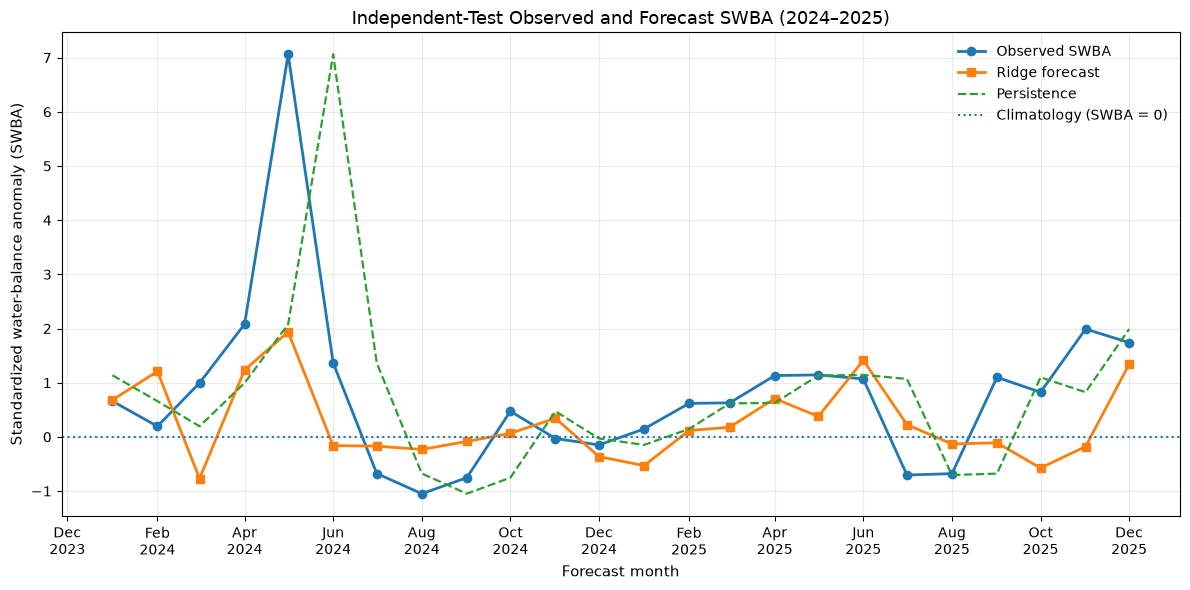

Figure saved to: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\figures\independent_test_forecasts.png


In [9]:
# ============================================================
# PUBLICATION FIGURE 1
# INDEPENDENT-TEST OBSERVED VS FORECAST SWBA
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

plot_data = (
    test_results
    .copy()
    .sort_values("forecast_date")
)

plot_data["forecast_date"] = pd.to_datetime(
    plot_data["forecast_date"]
)


# ------------------------------------------------------------
# 2. CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    plot_data["forecast_date"],
    plot_data["observed"],
    marker="o",
    linewidth=2,
    label="Observed SWBA"
)

ax.plot(
    plot_data["forecast_date"],
    plot_data["ridge_forecast"],
    marker="s",
    linewidth=2,
    label="Ridge forecast"
)

ax.plot(
    plot_data["forecast_date"],
    plot_data["persistence"],
    linestyle="--",
    linewidth=1.6,
    label="Persistence"
)

ax.axhline(
    y=0,
    linestyle=":",
    linewidth=1.5,
    label="Climatology (SWBA = 0)"
)


# ------------------------------------------------------------
# 3. FORMAT AXES
# ------------------------------------------------------------

ax.set_xlabel(
    "Forecast month",
    fontsize=11
)

ax.set_ylabel(
    "Standardized water-balance anomaly (SWBA)",
    fontsize=11
)

ax.set_title(
    "Independent-Test Observed and Forecast SWBA (2024–2025)",
    fontsize=13
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

fig.tight_layout()


# ------------------------------------------------------------
# 4. SAVE PUBLICATION-QUALITY VERSION
# ------------------------------------------------------------

output_path = (
    PROJECT_ROOT
    / "figures"
    / "independent_test_forecasts.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved to:",
    output_path
)

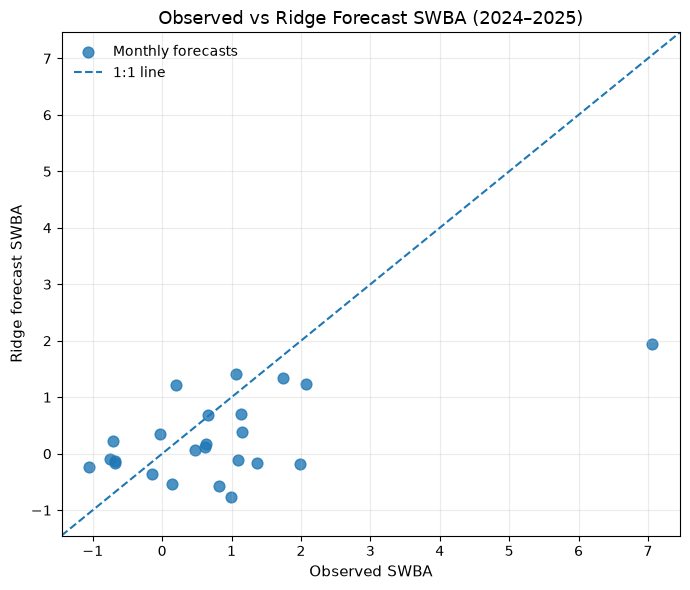

Figure saved to: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\figures\observed_vs_ridge_scatter.png


In [10]:
# ============================================================
# PUBLICATION FIGURE 2
# OBSERVED VS RIDGE FORECAST SWBA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

observed = test_results["observed"].to_numpy()
predicted = test_results["ridge_forecast"].to_numpy()


# ------------------------------------------------------------
# 2. DEFINE COMMON AXIS LIMITS
# ------------------------------------------------------------

# Using identical x- and y-axis limits makes the 1:1 reference
# line visually meaningful.

lower = min(
    observed.min(),
    predicted.min()
)

upper = max(
    observed.max(),
    predicted.max()
)

padding = 0.4

lower -= padding
upper += padding


# ------------------------------------------------------------
# 3. CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.scatter(
    observed,
    predicted,
    s=60,
    alpha=0.8,
    label="Monthly forecasts"
)


# ------------------------------------------------------------
# 4. ADD PERFECT-PREDICTION REFERENCE LINE
# ------------------------------------------------------------

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    label="1:1 line"
)


# ------------------------------------------------------------
# 5. FORMAT AXES
# ------------------------------------------------------------

ax.set_xlim(
    lower,
    upper
)

ax.set_ylim(
    lower,
    upper
)

ax.set_xlabel(
    "Observed SWBA",
    fontsize=11
)

ax.set_ylabel(
    "Ridge forecast SWBA",
    fontsize=11
)

ax.set_title(
    "Observed vs Ridge Forecast SWBA (2024–2025)",
    fontsize=13
)

ax.grid(
    alpha=0.25
)

ax.legend(
    frameon=False
)

fig.tight_layout()


# ------------------------------------------------------------
# 6. SAVE PUBLICATION-QUALITY FIGURE
# ------------------------------------------------------------

output_path = (
    PROJECT_ROOT
    / "figures"
    / "observed_vs_ridge_scatter.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved to:",
    output_path
)

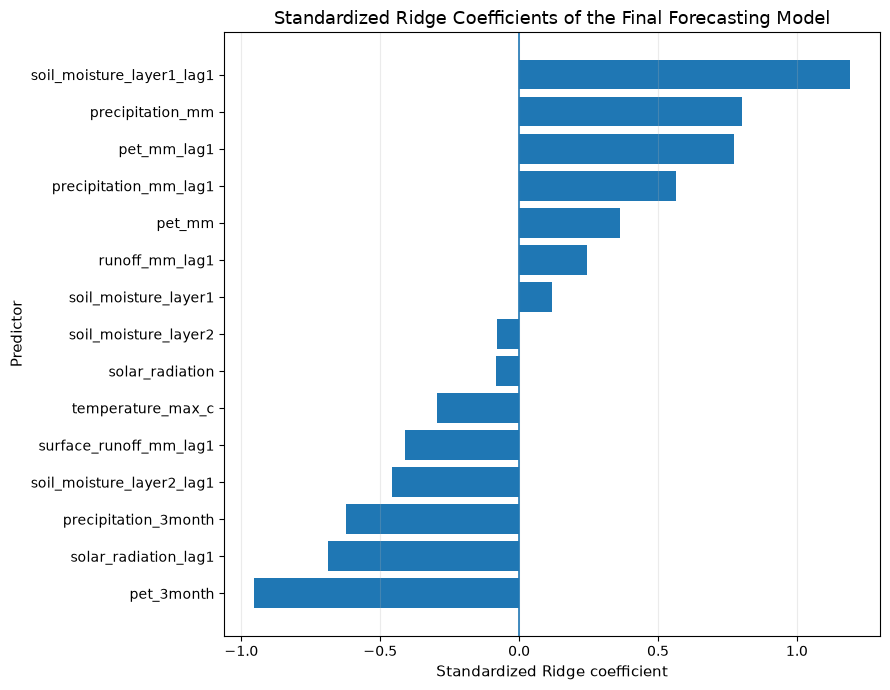

Figure saved to: c:\Users\Para\Desktop\Eswatini_Water_Stress_ML\figures\ridge_standardized_coefficients.png


In [11]:
# ============================================================
# PUBLICATION FIGURE 3
# STANDARDIZED RIDGE COEFFICIENTS
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. PREPARE COEFFICIENT DATA
# ------------------------------------------------------------

coefficient_plot = (
    coefficient_table
    .copy()
    .sort_values(
        "Coefficient",
        ascending=True
    )
)


# ------------------------------------------------------------
# 2. CREATE FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    coefficient_plot["Feature"],
    coefficient_plot["Coefficient"]
)


# ------------------------------------------------------------
# 3. REFERENCE LINE
# ------------------------------------------------------------

ax.axvline(
    x=0,
    linewidth=1.2
)


# ------------------------------------------------------------
# 4. FORMAT
# ------------------------------------------------------------

ax.set_xlabel(
    "Standardized Ridge coefficient",
    fontsize=11
)

ax.set_ylabel(
    "Predictor",
    fontsize=11
)

ax.set_title(
    "Standardized Ridge Coefficients of the Final Forecasting Model",
    fontsize=13
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()


# ------------------------------------------------------------
# 5. SAVE PUBLICATION-QUALITY FIGURE
# ------------------------------------------------------------

output_path = (
    PROJECT_ROOT
    / "figures"
    / "ridge_standardized_coefficients.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure saved to:",
    output_path
)

In [12]:
from pathlib import Path
import joblib

# Create models directory
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the complete fitted model/pipeline
model_path = models_dir / "water_stress_ridge.joblib"

joblib.dump(final_ridge, model_path)

print(f"Model saved to: {model_path.resolve()}")

Model saved to: C:\Users\Para\Desktop\Eswatini_Water_Stress_ML\models\water_stress_ridge.joblib


In [13]:
print(type(final_ridge))

if hasattr(final_ridge, "named_steps"):
    print(final_ridge.named_steps)

if hasattr(final_ridge, "feature_names_in_"):
    print("Features:")
    print(final_ridge.feature_names_in_)

<class 'sklearn.pipeline.Pipeline'>
{'imputer': SimpleImputer(strategy='median'), 'scaler': StandardScaler(), 'ridge': Ridge(alpha=0.05)}
Features:
['soil_moisture_layer1_lag1' 'precipitation_mm_lag1' 'pet_mm'
 'soil_moisture_layer2_lag1' 'precipitation_mm' 'soil_moisture_layer2'
 'precipitation_3month' 'soil_moisture_layer1' 'pet_mm_lag1'
 'temperature_max_c' 'surface_runoff_mm_lag1' 'runoff_mm_lag1'
 'pet_3month' 'solar_radiation' 'solar_radiation_lag1']


In [14]:
# First real observation from the test set
test_sample = X_test.iloc[[0]]

print("TEST INPUT:")
print(test_sample.to_dict(orient="records")[0])

print("\nNOTEBOOK PREDICTION:")
print(float(final_ridge.predict(test_sample)[0]))

TEST INPUT:
{'soil_moisture_layer1_lag1': 0.1950645211897267, 'precipitation_mm_lag1': 69.10055923208951, 'pet_mm': 190.4043430724729, 'soil_moisture_layer2_lag1': 0.1886460611440548, 'precipitation_mm': 195.9055574595876, 'soil_moisture_layer2': 0.2469986636864185, 'precipitation_3month': 360.4124523554093, 'soil_moisture_layer1': 0.2633401921000809, 'pet_mm_lag1': 238.24721432227088, 'temperature_max_c': 27.61313913944396, 'surface_runoff_mm_lag1': 0.0001684061456673, 'runoff_mm_lag1': 0.0001710179910763, 'pet_3month': 644.6355509467503, 'solar_radiation': 16949493.0308606, 'solar_radiation_lag1': 20575331.859687123}

NOTEBOOK PREDICTION:
0.6808269327320474


In [15]:
import json

test_payload = {
    feature: float(test_sample.iloc[0][feature])
    for feature in final_ridge.feature_names_in_
}

print(json.dumps(test_payload, indent=2))

{
  "soil_moisture_layer1_lag1": 0.1950645211897267,
  "precipitation_mm_lag1": 69.10055923208951,
  "pet_mm": 190.4043430724729,
  "soil_moisture_layer2_lag1": 0.1886460611440548,
  "precipitation_mm": 195.9055574595876,
  "soil_moisture_layer2": 0.2469986636864185,
  "precipitation_3month": 360.4124523554093,
  "soil_moisture_layer1": 0.2633401921000809,
  "pet_mm_lag1": 238.24721432227088,
  "temperature_max_c": 27.61313913944396,
  "surface_runoff_mm_lag1": 0.0001684061456673,
  "runoff_mm_lag1": 0.0001710179910763,
  "pet_3month": 644.6355509467503,
  "solar_radiation": 16949493.0308606,
  "solar_radiation_lag1": 20575331.859687123
}
